# Разведочный анализ данных

Поговорим об ещё одном этапе обработки данных в машинном обучении. 

При обработке данных можно выделить следующие этапы:

- Сбор данных
- Предобработка данных
- Анализ и визуализация или разведочный анализ данных (Exploratory Data Analysis, EDA)
- Генерация признаков (Feature Engineering)
- Выбор модели
- Обучение модели
- Оценка качества модели
- Внедрение модели 

Об этапах `сбора данных` и `внедрения модели` мы разговаривать не будем на нашем курсе. С этапами `предобработки данных` и `генерации признаков` мы говорили на предыдущем занятии. Этапам, связанным с `обучением моделей`, посвящён весь курс, а вот про этап `анализа данных` мы более подробно поговорим сейчас, хоть уже и немного занимались этим на предыдущем занятии.


Этот этап предполагает использование разных визуальных и статистических методов, направленное на выявление закономерностей и аномалий в данных, проверку гипотез и выявление взаимосвязи между признаками. 

Можно выделить следующие шаги:

- Понимание структуры данных: Сколько переменных? Какие они (числовые, категориальные)? Сколько наблюдений?
- Выявление проблем с данными: Пропущенные значения, выбросы, ошибки ввода. Эти проблемы могут исказить результаты любого анализа, если их не устранить.
- Обнаружение закономерностей и взаимосвязей: Есть ли корреляция между переменными? Как распределены данные? 
- Проверка исходных предположений: Подтверждаются ли наши предварительные идеи о данных?
- Формирование гипотез: На основе увиденных закономерностей мы можем выдвигать новые гипотезы для дальнейшего исследования.
- Выбор подходящих моделей: Понимание распределения данных и взаимосвязей помогает выбрать наиболее эффективные алгоритмы машинного обучения.
- Определение стратегии предобработки данных.


Загрузим набор данных Ирисов Фишера и проведём для него анализ, а потом применим модели для классификации.

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay

In [97]:
iris_df = pd.read_csv("/home/ivanbalashov/LearningMachine/six/Iris.csv", index_col="Id") 

Несколько строчек из набора данных:

In [98]:
iris_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


Посмотрим на основные статистические характеристики:

In [99]:
iris_df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Отобразим количество ирисов каждого вида:

In [100]:
print(iris_df['Species'].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Отобразим график <b>box-and-whiskers plot</b>, или просто box-plot, название которого иногда переводят буквально "ящик с усами", а иногда и более приятным термином "диаграмма размаха". Обычно на этом графике изображены:
- среднее или медиана $-$ линия в "ящике"
- первый и третий квартили $-$ границы "ящика"
- Полный размах данных изображается "усами", которые простираются от минимума до максимума. Иногда значения минимума и максимума подменяются на более консервативные значения, определяемые через межквартильный размах IQR (разница между значениям третьей и первой квартилью), а значения выходящие за границы отмечаются отдельно как выбросы. 

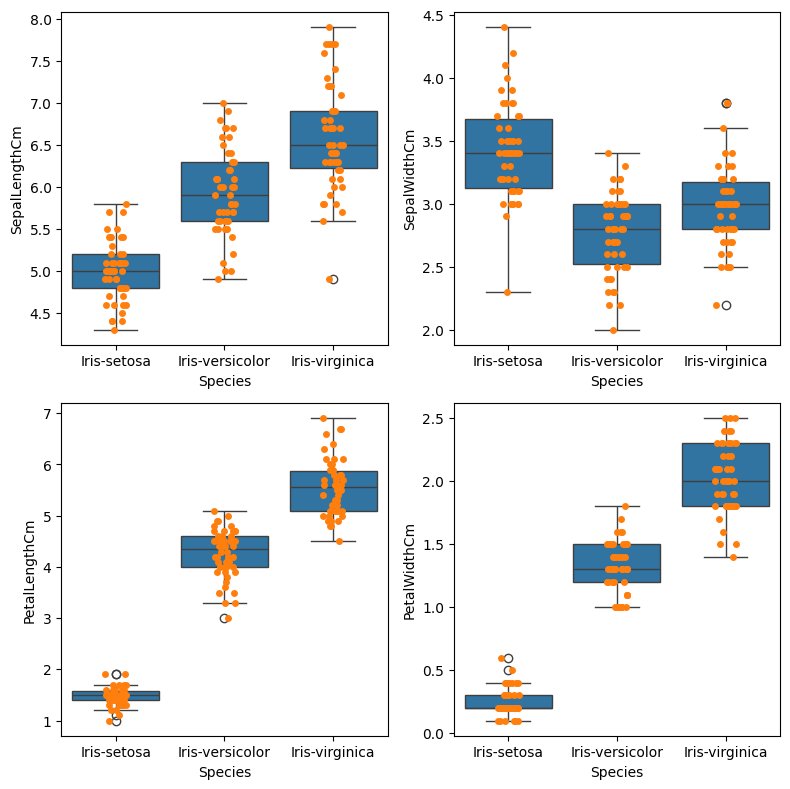

In [101]:
fig, axes = plt.subplots(2, 2)
fig.set_size_inches(8,8)
axes = axes.flatten()

for index, column in enumerate(["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]):
    sns.boxplot(x="Species", y=column, data=iris_df, ax=axes[index])
    sns.stripplot(x="Species", y=column, data=iris_df, ax=axes[index], jitter=True)
plt.tight_layout()

Также часто изображают попарные распределения признаков.

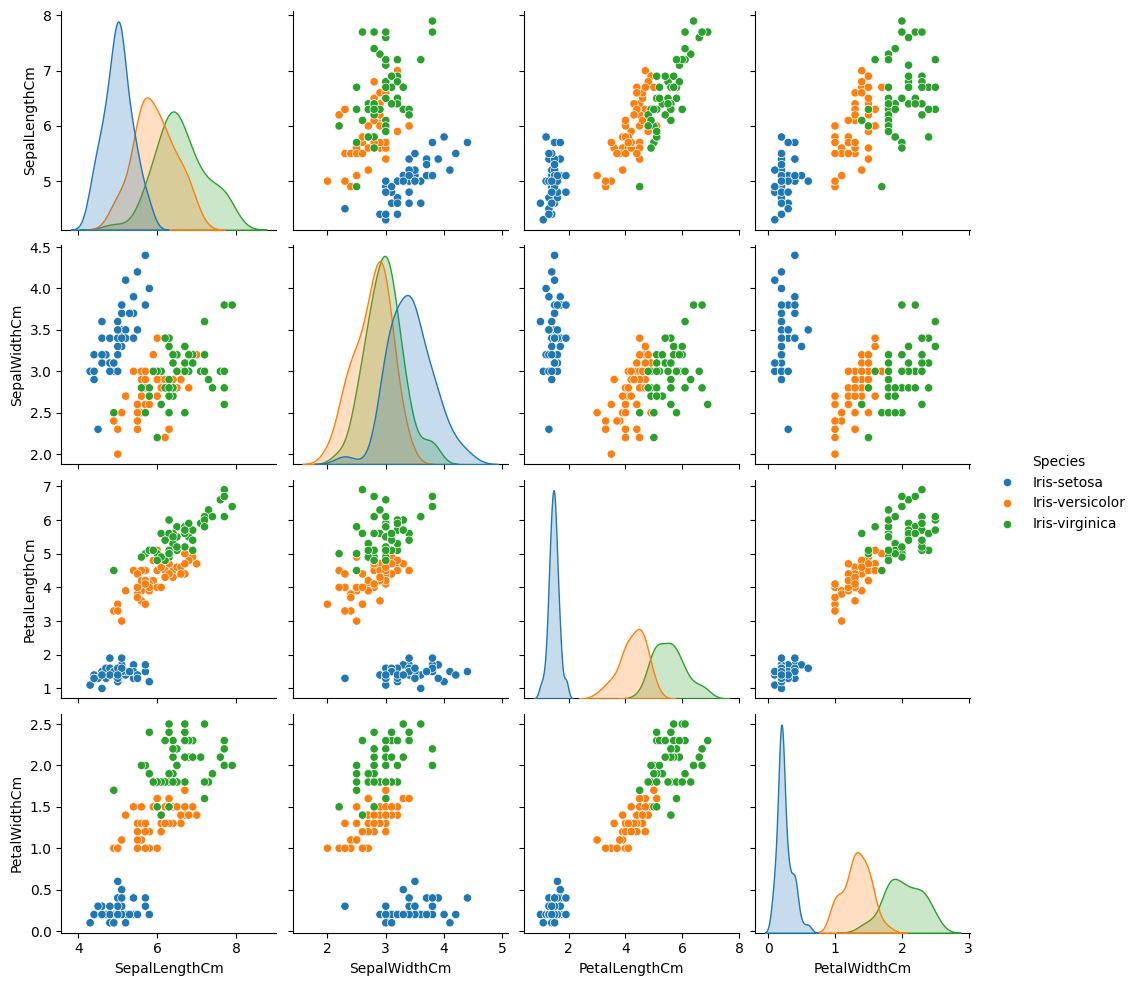

In [102]:
sns.pairplot(iris_df, hue="Species")

По этим графикам видно, что вид `Iris-setosa` можно отделить от других видов даже по всего одному признаку длины или ширины лепестка (PetalLength и PetalWidth). А вот с классами `Iris-versicolor` и `Iris-virginica` всё чуть сложнее, именно их мы и будем пытаться отличать, причём используя признаки длины и ширины чашелистика (SepalLength и SepalWidth).

Ну и наконец неплохо было бы взглянуть как сами ирисы выглядят:

<img style="width: 50%; max-width: 960px; display: block; margin: 0 auto;" src="https://user-images.githubusercontent.com/112110549/193254449-63fd39d3-03d4-46bd-bd3e-961e7b1147dc.png"/>

Из-за небольшого количества признаков в наборе данных на этом анализ данных и оканчивается. Но чем больше различных признаков различных типов в наборе данных, тем больше времени надо потратить на этот этап, тщательно исследуя данные.

И как вы видите, такой анализ данных мы уже проводили в задаче регрессии, просто мы не придавали ему особого значения.

# Метрики оценки качества классификации

Когда мы говорили о геометрическом смысле классификации мы определяли качество "на глаз". Но так не получится в большей размерности, да и метод оценки "на глаз" не подойдёт при более строгом подходе к задаче.

Снова начнём с бинарной классификации, а точнее с примера, когда идёт не просто классификация на 2 класса, а к примеру, мы имеем дело с результатом какого-нибудь теста, к примеру тест на заболевание. 

В таких тестах есть положительный ответ - наличие заболевания и отрицательный ответ - отсутствие заболевания. Тогда тест (или наша модель) может совершить ошибки двух видов:
- <b>ложные</b> или <b>ложноположительные срабатывания</b> (False Positive), также традиционно называемые <b>ошибками первого рода</b>. Ошибка возникает когда тест говорит что человек болен, а он на самом деле здоров.
- <b>пропуски событий</b> или <b>ложноотрицательные срабатывания</b> (False Negative), также традиционно называемые <b>ошибками второго рода</b>. Ошибка возникает когда тест говорит что человек здоров, а он на самом деле болен.

Вот таблицу с возможными вариантами комбинаций:

<table>
  <tbody>
    <tr>
      <th colspan="2" rowspan="2"></th>
      <th colspan="2">Действительность</th>
    </tr>
    <tr>
      <td>Да</td>
      <td>Нет</td>
    </tr>
    <tr>
      <td rowspan="2">Предсказание модели</td>
      <td>Да</td>
      <td>TP (Истинные положительные)</td>
      <td>FP (Ложноположительные)</td>
    </tr>
    <tr>
      <td>Нет</td>    
      <td>FN (Ложноотрицательные)</td>
      <td>TN (Истинные отрицательные)</td>
    </tr>
  </tbody>
</table>

Рассмотрим популярные метрики оценки качества классификации:
- <b>Точность (precision)</b> $-$ доля истинных положительных результатов среди всех положительных результатов:
$$Precision = \frac{TP}{TP+FP}$$
- <b>Полнота (recall)</b> $-$ доля выявленных положительных результатов:
$$Recall = \frac{TP}{TP+FN}$$
- <b>доля правильных ответов (accuracy)</b>:
$$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$$

Самые полезные и распространённые мы рассмотрели, но из TP, FP, FN, TN можно составить и другие показатели, которые используются в разных специфичных случаях, мы же остановимся на уже перечисленных.

Чем каждая из описанных метрик выше, тем лучше, но давайте разберёмся что каждая из них показывает.

Описанные метрики также можно проиллюстрировать такой картинкой: 
<img style="width: 50%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/8C0Gr3f5/Recall-Precision-2.webp"/>

Доля правильных ответов (Accuracy) $-$ это показатель, который хорошо отражает общее качество классификации, часто вполне достаточно использовать его. 

## Метрики на примере медицинского теста

Но также часто встречаются ситуации, когда в классах присутствует сильный перевес, и метрика доли правильных ответов перестаёт быть релевантной. Примером являются любые медицинские тесты: доля людей, подверженных какому-то заболеванию, из всей совокупности людей составляет лишь небольшую часть. Приведём пример в виде матрицы ошибок:

<table>
  <tbody>
    <tr>
      <th colspan="2" rowspan="2"></th>
      <th colspan="2">Болен</th>
    </tr>
    <tr>
      <td>Да</td>
      <td>Нет</td>
    </tr>
    <tr>
      <td rowspan="2">Результат теста</td>
      <td>Да</td>
      <td>1</td>
      <td>20</td>
    </tr>
    <tr>
      <td>Нет</td>    
      <td>9</td>
      <td>970</td>
    </tr>
  </tbody>
</table>

Понимать эту таблице стоит так:

- 1 больной человек получил положительный результат теста,
- 9 больных человек получили отрицательные результаты теста,
- 20 здоровых людей получили положительный результат теста,
- 970 здоровых людей получили отрицательный результат теста.


Посчитаем долю правильных ответов:

$Accuracy = \frac{1+970}{1+9+20+970}=\frac{971}{1000}=0.971$

Получили значение $0.971$, что очень недалеко от максимального значения 1. После этого можно констатировать, что тест очень эффективен и надо его срочно внедрять, но не будем торопиться.

На деле оказывается, что из 10 больных тест выявил только 1, но выявление больных и есть основная задача теста. Связано такое искажение непосредственно с тем, что из общей выборки в 1000 человек больными были лишь 10.

Зато намного более полезно этом случае будет посмотреть метрику полноты:

$Recall = \frac{1}{1+9}=\frac{1}{10}$

Получили значение $0.1$, что отражает, что из 10 больных обнаружен был (и будет при использовании теста в будущем) только один, что нас явно не устраивает.

Также полезно посмотреть на метрику точности:

$Precision = \frac{1}{1+20} = \frac{1}{21}$

Получаем значение примерно $0.047 \approx 0.05$, что означает, что из 20 положительных тестов только 1 указывает на действительно больного человека.

Стоит отметить, что в медицинских тестах цена ошибок разная. Не выявить больного человека намного хуже чем выдать положительный ответ здоровому человеку. Невыявленный больной скорее всего после теста успокоится, а заболевание продолжит прогрессировать. А вот здоровый человек, получивший положительный тест, безусловно, будет переживать, но он сможет сделать более точный тест, который развеет его тревоги.

----------------

## Точность vs. Полнота

Но если доля правильных ответов часто оказывается не релевантной, то что же делать с показателями точности и полноты? Этих показателей целых два! 

- Если сосредоточиться на полноте, то окажется, что надо всем людям выдавать положительный результат, тогда мы точно ни одного больного не пропустим. 
- Если сосредоточиться на точности, то наоборот всем надо выдавать отрицательные тесты, тогда не один здоровый человек не будет попусту переживать. 

Тут сразу можно заметить, что мы можем даже без перестройки модели машинного обучения менять её "чувствительность" (если, конечно, выбранная модель позволяет). Уменьшая порог срабатывания теста, мы можем увеличивать полноту, но вместе с этим уменьшать точность, а увеличивая порог срабатывания, мы можем увеличить точность, но уменьшать полноту.

Это можно в целом заметить про обучение моделей машинного обучения. Мы постоянно пытаемся нащупать баланс между количеством ложноположительных и ложноотрицательных ответов. Надеяться на то, что в настоящих задачах ложных ответов не будет совсем, не приходится. 

Случаи же когда удаётся достичь увеличения и точности и полноты чаще всего связаны с качественным улучшением используемой модели. Это может быть переход к другой модели, уточнение предположений о данных, улучшение метода предобработки данных и другие улучшения.

Необходимо обращать внимание сразу на оба показателя. Но как?

Что лучше? Полнота $0.9$ и точность $0.87$ или полнота $0.83$ и точность $0.94$? Безусловно это зависит от задачи, но всё же как привести два показателя к единой шкале?

-------------------

## F-мера

Ответом на данный вопрос является применение <b>F-меры</b>. 


<b>Сбалансированная F-мера</b> или F1-мера (F1 score) определяется как среднее гармоническое точности и полноты:

$$F1\_score=\frac{2}{\frac{1}{Recall}+\frac{1}{Precision}}=2\frac{Precision\cdot Recall}{Precision+Recall} = \frac{2TP}{2TP+FP+FN}$$

Значение F-меры также принимает значения от 0 до 1, а её нелинейность также добавляет полезное свойство: если хотя-бы один из показателей мал, то F-мера мала.

Нарисует тепловую карту F-меры:

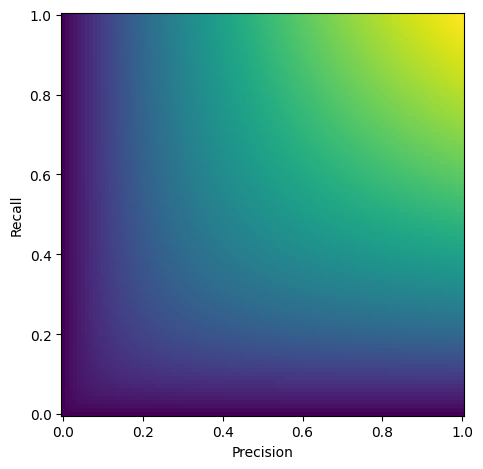

In [103]:
p = np.linspace(0.001, 1, 101)
r = np.linspace(0.001, 1, 101)
p, r = np.meshgrid(p, r)
f1 = 2/(1/r+1/p)
plt.pcolormesh(p, r, f1, vmin=0, vmax=1)
plt.gca().set_aspect("equal")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.tight_layout()


Как мы отмечали ранее, цена разных ошибок - разная, поэтому есть более общий вариант F-меры.

<b>$F_\beta$-мера</b> описывается следующим образом:

$$F_\beta\_score=\frac{\beta^2+1}{\frac{\beta^2}{Recall}+\frac{1}{Precision}}$$

Параметр $\beta$ как раз позволяет сместить баланс в ту или иную сторону. Тоже изобразим это на тепловой карте:

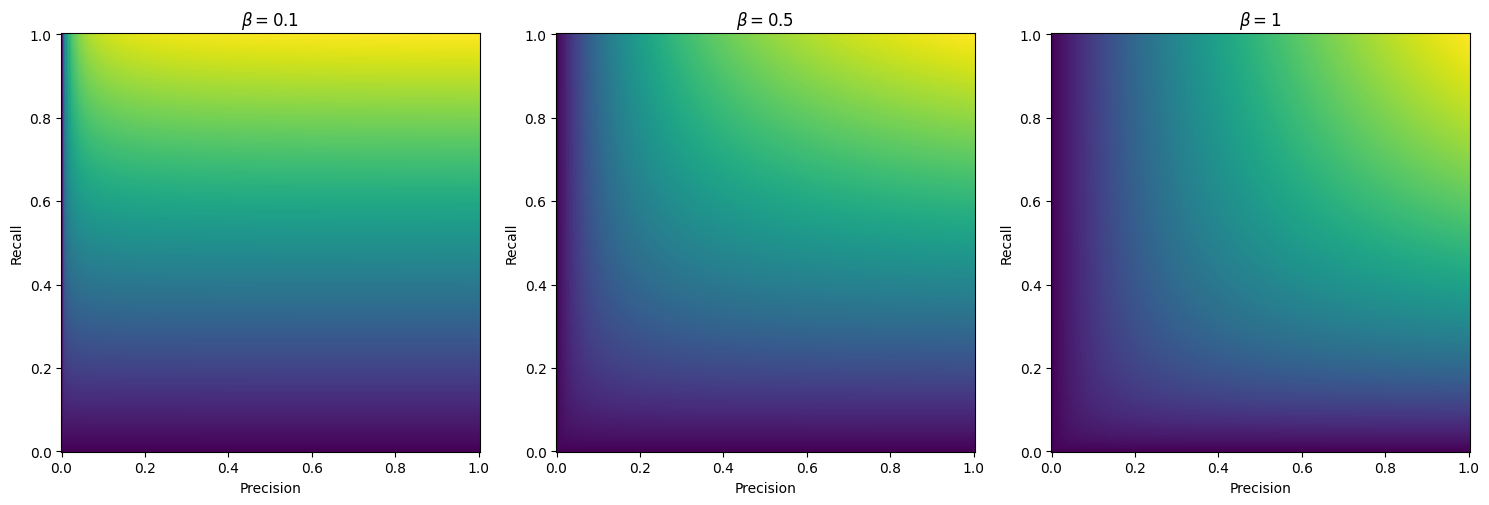

In [104]:
p = np.linspace(0.001, 1, 301)
r = np.linspace(0.001, 1, 301)
p, r = np.meshgrid(p, r)
betas = [0.1, 0.5,1]
fig, axes = plt.subplots(1,3)
axes = axes.flatten()


for index, beta in enumerate(betas):
    f1 = (beta**2 +1 )/(1/r+(beta**2)/p)
    axes[index].pcolormesh(p, r, f1, vmin=0, vmax=1)
    axes[index].set_aspect("equal")
    axes[index].set_xlabel("Precision")
    axes[index].set_ylabel("Recall")
    axes[index].set_title(f"$\\beta={beta}$")
fig.set_size_inches(15, 5)
plt.tight_layout()

## Метрики для многоклассовой классификации

Но всё выше перечисленное относилось к классификации на 2 класса, причём к случаю, где нас интересовал только один класс (ответ "да"). Для нескольких классов матрица ошибок просто будет иметь больше строк и столбцов. Приведём пример для четырёх классов:

<table>
  <tr>
    <th colspan="2" rowspan="2"></th>
    <th colspan="4">Истинный класс</th>
  </tr>
  <tr>
    <th>A</th><th>B</th><th>C</th><th>D</th>
  </tr>
  <tr>
    <td rowspan="4">Предсказанный класс</td>
    <td>A</td>
    <td>a₁₁</td><td>a₁₂</td><td>a₁₃</td><td>a₁₄</td>
  </tr>
  <tr>
    <td>B</td>
    <td>a₂₁</td><td>a₂₂</td><td>a₂₃</td><td>a₂₄</td>
  </tr>
  <tr>
    <td>C</td>
    <td>a₃₁</td><td>a₃₂</td><td>a₃₃</td><td>a₃₄</td>
  </tr>
  <tr>
    <td>D</td>
    <td>a₄₁</td><td>a₄₂</td><td>a₄₃</td><td>a₄₄</td>
  </tr>
</table>

С метрикой доли правильных ответов в случае нескольких классов всё просто, она равна отношению суммы на диагонали к сумме по всей марице:

$$Accuracy=\frac{\sum_{i=1}^na_{ii}}{\sum_{i=1}^n\sum_{j=1}^na_{ij}}$$

А метриками Точности и Полноты есть два варианта вычисления: микро- и макро-усреднение. 


### Микро-усреднение

При микро усреднении для Точности работает следующая схема: 

Мы вычисляем Точность как частное истинно положительных ответов(TP) и суммы истинно положительных ответов(TP) и ложно положительных ответов(FP) для каждого класса, записанных под общий знаменатель.

Истинно положительные ответы и ложно положительные ответы определяются следующими формулами:

FP $-$ сумма элементов в строчке, кроме элемента на диагонали: $FP_i=\sum_{j=1,j\neq i}^na_{ij}$;

TP $-$ элемент на диагонали: $TP_i=a_{ii}$.

В результате мы получим такую формулу: 

$$Precision=\frac{\sum_{i=1}^MTP_i}{\sum_{i=1}^M(TP_i + FP_i)} = \frac{\sum_{i=1}^Ma_{ii}}{\sum_{i=1}^M(a_{ii}+\sum_{j=1,j\neq i}^Ma_{ij})} = \frac{\sum_{i=1}^Ma_{ii}}{\sum_{i=1}^M\sum_{j=1}^Ma_{ij}}.$$

Аналогично получим и для Полноты:

$$Recall = \frac{\sum_{i=1}^MTP_i}{\sum_{i=1}^M(TP_i + FN_i)} = \frac{\sum_{i=1}^Ma_{ii}}{\sum_{i=1}^M\sum_{j=1}^Ma_{ij}}.$$

При микро-усреднении формулы метрик точности, полноты и доли правильных ответов совпадают. А мы уже отмечали проблемы метрики доли правильных ответов и теперь эти недостатки распространились на все метрики. 

Но это замечание справедливо только пока мы ведём классификацию с единственными метками (single-label), когда одна отметка исключает другую. Формулы будут отличаться в случае, если используется множественные метки (multi-label), то есть результаты мы кодируем уже не one-hot вектором, а булевым вектором, отражающим принадлежность объекта сразу нескольким классам.

[1,0,0,1] -> объект принадлежит классам 1 и 4. 

Подробно мы рассматривать случай для множественных отметок не будем, поговорим о нём в будущем, если столкнёмся с такой задачей.

А пока отметим, что вам <b>использовать микро-усреднение запрещено.</b> 😀

### Макро-усреднение

Второй метод основан на следующей идее: мы относительно каждого класса рисуем отдельную табличку с ответами "да" и "нет", отображающими принадлежность объекта классу, далее считаем для каждого класса по полученной табличке метрики точности и полноты, а потом усредняем.

$$Precision=\frac{1}{M}\sum_{i=1}^{M}Precision_{C_i}, \;\; Recall=\frac{1}{M}\sum_{i=1}^{M}Recall_{C_i},$$

где $Precision_{C_i}$ и $Recall_{C_i}$ - точность и полнота для класса $C_i$.

Ну и наконец стоит отметить, что полезно смотреть и на метрики точности и полноты для каждого класса в отдельности. Поскольку Макро-усреднённые точность и полнота это среднее, они отражают лишь общую картину, за которой можно не заметить плохое качество на отдельном классе.

А теперь вернёмся к ирисам и методу knn. Мы бы хотели выбрать оптимальное количество ближайших соседей, но оптимизировать этот параметр как мы делали ранее не получится. Градиент мы посчитать не можем. 

И с этим параметром не всё так просто. Ранее, темп обучения и количество эпох влияли на скорость работы и сходимость метода градиентного спуска, но итог обучения всегда один $-$ некоторый локальный минимум (если метод, конечно, сошёлся). А вот от количества соседей зависит качество получаемой модели, поэтому необходимо найти наилучшее значение этого параметра.

# Демонстрация вычисления метрик

In [105]:
def generate_samples(n_points, mean, cov, target):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    return X, Y

def plot_classifier(X, Y, model = None):
    # Границы отрисовки
    xmin, xmax = X[:,0].min()-3, X[:,0].max()+3
    ymin, ymax = X[:,1].min()-3, X[:,1].max()+3
    if model:
        x = np.linspace(xmin, xmax, 300)
        y = np.linspace(ymin, ymax, 300)
        # создаём две матрицы с координатами x и y
        x, y = np.meshgrid(x, y)
        # Преобразуем матрицу в строчку
        xx = x.reshape(-1,1)
        yy = y.reshape(-1,1)
        points = np.hstack([xx,yy])
        # Передаём строчку точек в функцию
        probs = model.predict(points)
        # Преобразуем строчку обратно в матрицу
        probs = probs.reshape(x.shape)
        # рисуем деление плоскости на классы
        plt.pcolormesh(x, y, probs, cmap="tab10",vmax=10)
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="bright", legend=False)
    plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

from sklearn.base import BaseEstimator, ClassifierMixin

class FixedClassifier(BaseEstimator, ClassifierMixin):
    
    def __init__(self, a):
        """
            Задаёт фиксированную разделяющую поверхность вида
            a_0 + a_1 x_1 + ... a_n x_n = 0
        """
        super().__init__()
        self.a = a
        
    def fit(self, X, Y):
        return self
    
    def predict(self, X):
        rez = self.a[0] + X @ self.a[1:]
        return rez > 0
    

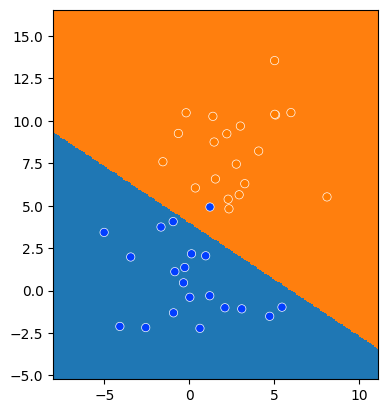

In [106]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([20, 20])
target = np.array([0, 1])
# Среднее центров гауссианов
mean = np.array([[0, 0], [3, 8]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 6]],
     [[6, 0],
      [0, 6]]]
    )
np.random.seed(43)
X,Y = generate_samples(n_points, mean, cov, target)

model = FixedClassifier(np.array([-12, 2, 3]))
plot_classifier(X, Y, model)

Всего в выборке 40 объектов: по 20 в каждом классе.

Мы провели прямую $-12+2x_1+3x_2=0$.

Давайте посчитаем разные метрики:

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Доля правильных ответов: ", accuracy_score(Y, model.predict(X)))
print("---")
print("Точность для оранжевого класса: ", precision_score(Y, model.predict(X), pos_label=1, average="binary"))
print("Точность для синего класса: ", precision_score(Y, model.predict(X), pos_label=0, average="binary"))
print("Точность с макро-усреднением:", precision_score(Y, model.predict(X), average="macro"))
print("---")
print("Полнота для оранжевого класса: ", recall_score(Y, model.predict(X), pos_label=1, average="binary"))
print("Полнота для синего класса: ", recall_score(Y, model.predict(X), pos_label=0, average="binary"))
print("Полнота с макро-усреднением:", recall_score(Y, model.predict(X), average="macro"))
print("---")
print("F-мера:", f1_score(Y, model.predict(X), average="macro"))

Доля правильных ответов:  0.975
---
Точность для оранжевого класса:  0.9523809523809523
Точность для синего класса:  1.0
Точность с макро-усреднением: 0.9761904761904762
---
Полнота для оранжевого класса:  1.0
Полнота для синего класса:  0.95
Полнота с макро-усреднением: 0.975
---
F-мера: 0.9749843652282677


Доля правильных ответов:  0.9920792079207921
---
Точность для оранжевого класса:  0.9920634920634921
Точность для синего класса:  1.0
Точность с макро-усреднением: 0.996031746031746
---
Полнота для оранжевого класса:  1.0
Полнота для синего класса:  0.2
Полнота с макро-усреднением: 0.6
---
F-мера: 0.6646746347941567


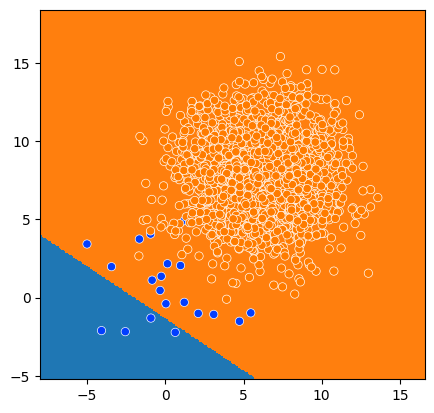

In [108]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([20, 2000])
target = np.array([0, 1])
# Среднее центров гауссианов
mean = np.array([[0, 0], [6, 8]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 6]],
     [[6, 0],
      [0, 6]]]
    )
np.random.seed(43)
X,Y = generate_samples(n_points, mean, cov, target)

model = FixedClassifier(np.array([4, 2, 3]))
plot_classifier(X, Y, model)

print("Доля правильных ответов: ", accuracy_score(Y, model.predict(X)))
print("---")
print("Точность для оранжевого класса: ", precision_score(Y, model.predict(X), pos_label=1, average="binary"))
print("Точность для синего класса: ", precision_score(Y, model.predict(X), pos_label=0, average="binary"))
print("Точность с макро-усреднением:", precision_score(Y, model.predict(X), average="macro"))
print("---")
print("Полнота для оранжевого класса: ", recall_score(Y, model.predict(X), pos_label=1, average="binary"))
print("Полнота для синего класса: ", recall_score(Y, model.predict(X), pos_label=0, average="binary"))
print("Полнота с макро-усреднением:", recall_score(Y, model.predict(X), average="macro"))
print("---")
print("F-мера:", f1_score(Y, model.predict(X), average="macro"))

Доля правильных ответов:  0.996039603960396
---
Точность для оранжевого класса:  0.9994984954864594
Точность для синего класса:  0.7307692307692307
Точность с макро-усреднением: 0.8651338631278451
---
Полнота для оранжевого класса:  0.9965
Полнота для синего класса:  0.95
Полнота с макро-усреднением: 0.97325
---
F-мера: 0.9120419760074895


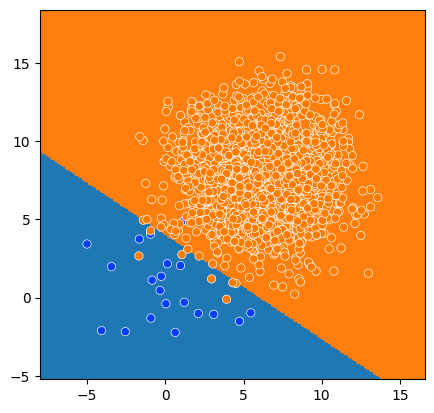

In [109]:
# Задаём параметры для генерации точек
# Количество точек
n_points = np.array([20, 2000])
target = np.array([0, 1])
# Среднее центров гауссианов
mean = np.array([[0, 0], [6, 8]])
# Матрицы коварианцй
cov = np.array(
    [[[6, 0],
      [0, 6]],
     [[6, 0],
      [0, 6]]]
    )
np.random.seed(43)
X,Y = generate_samples(n_points, mean, cov, target)

model = FixedClassifier(np.array([-12, 2, 3]))
plot_classifier(X, Y, model)

print("Доля правильных ответов: ", accuracy_score(Y, model.predict(X)))
print("---")
print("Точность для оранжевого класса: ", precision_score(Y, model.predict(X), pos_label=1, average="binary"))
print("Точность для синего класса: ", precision_score(Y, model.predict(X), pos_label=0, average="binary"))
print("Точность с макро-усреднением:", precision_score(Y, model.predict(X), average="macro"))
print("---")
print("Полнота для оранжевого класса: ", recall_score(Y, model.predict(X), pos_label=1, average="binary"))
print("Полнота для синего класса: ", recall_score(Y, model.predict(X), pos_label=0, average="binary"))
print("Полнота с макро-усреднением:", recall_score(Y, model.predict(X), average="macro"))
print("---")
print("F-мера:", f1_score(Y, model.predict(X), average="macro"))

## Кросс-валидация

Как мы обсуждали на предыдущем занятии, результат метода ближайших соседей сильно зависит от гиперпараметров. Но обучить эти гиперпараметры мы не можем. Градиент по ним не считается, зависимость не монотонная. 

Решить проблему подбора параметров помогает подход кросс-валидации.

Идея довольно простая: Давайте будем перебирать возможные параметры модели и выберем те параметры, при которых модель будет работать лучше всего. 

Но как оценивать качество? 
- Оценка на обучающей выборке, как мы знаем, не отражает способность модели обобщаться.
- Оценивать на тестовой выборке тоже будет не честно, поскольку в таком случае мы подберём параметры, чтобы модель была наилучшей на тестовой выборке. Но такая оценка снова не будет отражать способность модели к обобщению. Для другой тестовой выборки результат может быть совсем другим.

Но тут ещё важно заметить, что если мы отделим ещё одну выборку от обучающей и будем подбирать модели для неё. То окажется, что мы:
- Снова переобучили модель на конкретных данных.
- Уменьшили обучающую выборку. А для метода ближайших соседей это очень критично, поскольку данные и есть "веса" модели.

Поэтому для оценки модели используется подход **Кросс-валидации**. Этот метод также иногда называют **KFold**. Состоит он в следующем:

- Выборка разбивается на $k$ одинаковых по размеру частей. $k$ обычно небольшое, в рамках от 5 до 10.
- Далее происходит $k$ итераций, когда модель обучается на $k-1$ части и тестируется на одной оставшейся.
- Качество модели оценивается как усреднение оценок, полученных на каждой итерации.


<img style="width: 50%; max-width: 960px; display: block; margin: 0 auto; background-color: white;" src="https://scikit-learn.org/stable/_images/grid_search_cross_validation.png" />

Нам остаётся только выбрать лучшую модель и проверить как она работает на тестовой выборке.

<b>Замечание</b>

Сам перебор параметров можно вести по разным стратегиям. 
- Можно перебирать параметры "по сетке". `GridSearch`
- Можно генерировать случайно из заданного диапазона. `RandomSearch`
- Лучшим вариантом для подбора параметров является более умный перебор параметров. Поскольку мы производим эксперименты большое количество раз, то у нас накапливается информация о влиянии параметров на результат. Можно попытаться использовать эти знания для улучшения перебора.
    - Можно исключить из рассмотрения заведомо плохие конфигурации параметров.
    - Можно пытаться улучшить уже хорошие результаты.
    - Можно проверять те конфигурации параметров, про которые у нас мало информации.
    
    Такой метод является классической идеей эвристических алгоритмов, основанных на комбинации фаз Exploration и Exploitation (исследование и использование).
    Такой метод реализован в библиотеке `optuna`.

In [110]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

iris_df = pd.read_csv("/home/ivanbalashov/LearningMachine/six/Iris.csv", index_col="Id") 
X = iris_df[["SepalLengthCm", "SepalWidthCm"]].to_numpy()
encoder = LabelEncoder()
Y = encoder.fit_transform(iris_df["Species"])

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

cv = GridSearchCV(KNeighborsClassifier(), param_grid={
    "n_neighbors": np.arange(1,100),         # Перебор Количество ближайших соседей
    "weights": ["uniform", "distance"]      # Перебор распределения весов между соседями
}, 
scoring="accuracy", # Метрика оценки качества доля правильных ответов
cv=5)               # разбиение выборки на 5 частей для кросс-валидации

cv.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 1, 2..., 97, 98, 99]), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

In [111]:
def draw_knn(model, X, Y):
    xmin, xmax = X[:, 0].min(),X[:, 0].max()
    ymin, ymax = X[:, 1].min(),X[:, 1].max()
    x = np.linspace(xmin, xmax, 200)
    y = np.linspace(ymin, ymax, 200)
    x, y = np.meshgrid(x, y)

    DecisionBoundaryDisplay.from_estimator(model, X=X,response_method="predict", xlabel="SepalLengthCm", ylabel="SepalWidthCm", alpha=0.5)

    sns.scatterplot(x=X[:,0],y=X[:,1],hue=Y)

Лучшее качество: 0.8333333333333334
Оптимальное количество соседей: 35
Оптимальное распределение весов: uniform
Полученная разделяющая поверхность:


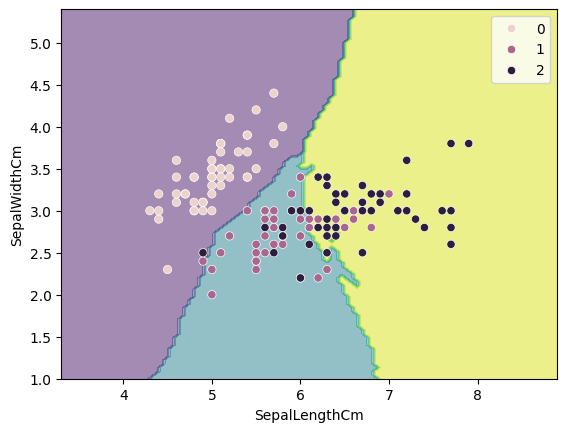

In [112]:
print(f"Лучшее качество: {cv.best_score_}")
print(f"Оптимальное количество соседей: {cv.best_estimator_.n_neighbors}")
print(f"Оптимальное распределение весов: {cv.best_estimator_.weights}")
print(f"Полученная разделяющая поверхность:") 
draw_knn(cv.best_estimator_, X, Y)

Можно посмотреть результаты всех обучений:

In [113]:
cv_df = pd.DataFrame(cv.cv_results_)
cv_df.head(3)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000566,0.000051,0.001497,0.000097,1,uniform,"{'n_neighbors': 1, 'weights': 'uniform'}",0.7,0.733333,0.7,0.866667,0.666667,0.733333,0.069921,192
1,0.000517,0.000016,0.000941,0.000029,1,distance,"{'n_neighbors': 1, 'weights': 'distance'}",0.7,0.733333,0.7,0.866667,0.666667,0.733333,0.069921,192
2,0.000542,0.000017,0.001450,0.000033,2,uniform,"{'n_neighbors': 2, 'weights': 'uniform'}",0.7,0.766667,0.7,0.866667,0.666667,0.740000,0.071181,178


Нарисуем зависимость качества модели от параметров:

Text(0, 0.5, 'Доля правильных ответов')

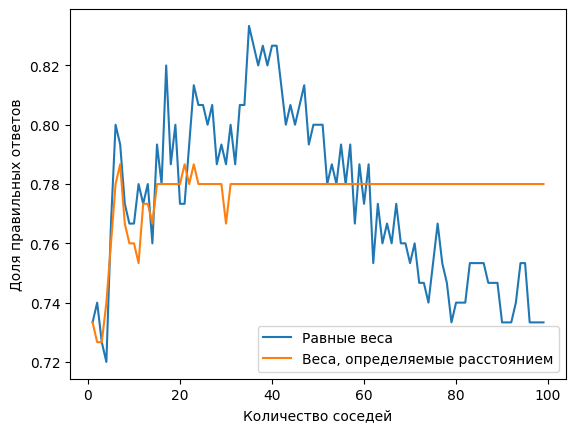

In [114]:
mask = cv_df["param_weights"] == "uniform"
plt.plot(cv_df[mask]["param_n_neighbors"], cv_df[mask]["mean_test_score"], label="Равные веса")
mask = cv_df["param_weights"] != "uniform"
plt.plot(cv_df[mask]["param_n_neighbors"], cv_df[mask]["mean_test_score"], label="Веса, определяемые расстоянием")
plt.legend()
plt.xlabel("Количество соседей")
plt.ylabel("Доля правильных ответов")

# Домашнее Задание:

- Обучите модели LDA, QDA и KNN для классификации ирисов фишера, вычислите метрики качества для каждой модели. Для knn попробуйте использовать разное количество ближайших соседей, разные расстояния и разные распределения весов. Не используйте кросс валидацию, попробуйте "угадать" параметры.
- Автоматизируйте поиск оптимальных параметров для knn с помощью кросс-валидации.

In [115]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

iris_df = pd.read_csv("/home/ivanbalashov/LearningMachine/six/Iris.csv", index_col="Id") 
X = iris_df[["SepalLengthCm", "SepalWidthCm"]].to_numpy()
encoder = LabelEncoder()
Y = encoder.fit_transform(iris_df["Species"])

In [116]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=5, test_size=0.3,
                                                    stratify=Y) # При разделении сохраняет соотношение классов

Точки данных в обучающей выборке:

<Axes: >

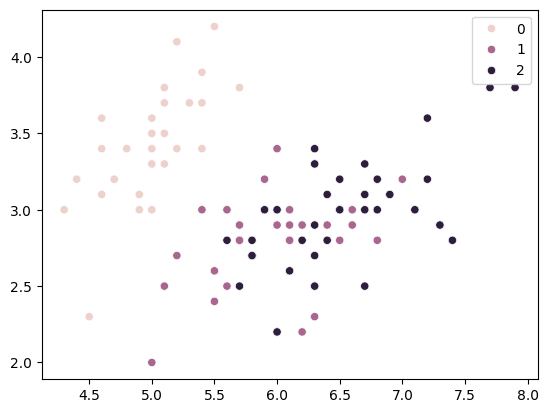

In [117]:
sns.scatterplot(x=X_train[:,0], y=X_train[:,1], hue=Y_train)

Точки данных в тестовой выборке:

<Axes: >

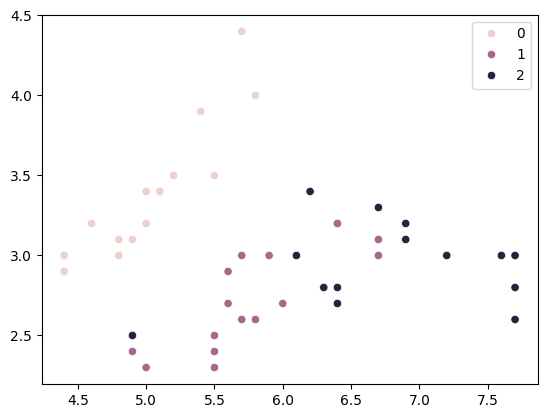

In [118]:
sns.scatterplot(x=X_test[:,0], y=X_test[:,1], hue=Y_test)

In [119]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [120]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

iris_df = pd.read_csv("/home/ivanbalashov/LearningMachine/six/Iris.csv", index_col="Id") 
X = iris_df[["SepalLengthCm", "SepalWidthCm"]].to_numpy()
encoder = LabelEncoder()
Y = encoder.fit_transform(iris_df["Species"])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=5, test_size=0.3,
                                                    stratify=Y)


modelLDA = LinearDiscriminantAnalysis()
modelLDA.fit(X_train, Y_train)

modelQDA = QuadraticDiscriminantAnalysis()
modelQDA.fit(X_train, Y_train)

print("Доля правильных ответов для LDA: ", accuracy_score(Y_test, modelLDA.predict(X_test)))
print(classification_report(Y_test, modelLDA.predict(X_test), 
                           target_names=encoder.classes_))


print("Доля правильных ответов для QDA: ", accuracy_score(Y_test, modelQDA.predict(X_test)))
print(classification_report(Y_test, modelQDA.predict(X_test), 
                           target_names=encoder.classes_))



Доля правильных ответов для LDA:  0.8666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.80      0.80      0.80        15
 Iris-virginica       0.80      0.80      0.80        15

       accuracy                           0.87        45
      macro avg       0.87      0.87      0.87        45
   weighted avg       0.87      0.87      0.87        45

Доля правильных ответов для QDA:  0.8666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.80      0.80      0.80        15
 Iris-virginica       0.80      0.80      0.80        15

       accuracy                           0.87        45
      macro avg       0.87      0.87      0.87        45
   weighted avg       0.87      0.87      0.87        45



In [135]:

modelKNN = KNeighborsClassifier(n_neighbors=29, weights='uniform')
modelKNN.fit(X_train, Y_train)
print("Доля правильных ответов для KNN: ", accuracy_score(Y_test, modelKNN.predict(X_test)))
print(classification_report(Y_test, modelKNN.predict(X_test), 
                           target_names=encoder.classes_))

Доля правильных ответов для KNN:  0.9111111111111111
                 precision    recall  f1-score   support

    Iris-setosa       0.94      1.00      0.97        15
Iris-versicolor       1.00      0.80      0.89        15
 Iris-virginica       0.82      0.93      0.88        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45



In [132]:
cv = GridSearchCV(KNeighborsClassifier(), param_grid={
    "n_neighbors": np.arange(1,36),
    "weights": ["uniform", "distance"]
}, 
scoring="accuracy",
cv=20) 
cv.fit(X, Y)
print(f"Лучшее качество: {cv.best_score_}")
print(f"Оптимальное количество соседей: {cv.best_estimator_.n_neighbors}")
print(f"Оптимальное распределение весов: {cv.best_estimator_.weights}")


Лучшее качество: 0.8205357142857144
Оптимальное количество соседей: 29
Оптимальное распределение весов: uniform
